# 📊 Marketing Channel Regression Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import warnings

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
%matplotlib inline

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [2]:
# Create a realistic marketing dataset
np.random.seed(42)
n = 200

TV           = np.random.uniform(10, 300, n)
Radio        = np.random.uniform(5,  100, n)
Social_Media = np.random.uniform(1,  50,  n)

# Sales is mostly driven by TV, slightly by Radio
Sales = (5
         + 0.055 * TV
         + 0.12  * Radio
         + 0.05  * Social_Media
         + np.random.normal(0, 1.5, n))

df = pd.DataFrame({'TV': TV, 'Radio': Radio,
                   'Social_Media': Social_Media, 'Sales': Sales})

# Save as CSV so you can open it in Excel too
df.to_csv('marketing_data.csv', index=False)
print('✅ Dataset created!')
print('Shape:', df.shape)

✅ Dataset created!
Shape: (200, 4)


In [3]:
# See the first 5 rows
print('First 5 rows of our dataset:')
df.head()

First 5 rows of our dataset:


,TV,Radio,Social_Media,Sales
0,118.616634,65.993006,6.053070,18.950343
1,285.707149,12.993297,45.225092,23.345034
2,222.278243,20.354728,25.757366,20.795193
3,183.610960,90.362648,41.496416,26.464078
4,55.245406,62.610761,16.682430,15.555436


In [4]:
# Check basic statistics of every column
print('📊 Summary Statistics:')
print(df.describe().round(2))

# Check for missing values
print('\nMissing values per column:')
print(df.isnull().sum())

# Remove any missing rows (just in case)
df = df.dropna()
print('\n✅ Data is clean! Rows remaining:', len(df))

📊 Summary Statistics:
           TV   Radio  Social_Media   Sales
count  200.00  200.00        200.00  200.00
mean   150.36   52.92         26.51   20.86
std     85.52   27.84         15.06    5.79
min     11.60    5.48          1.53    5.86
25%     76.29   29.84         13.52   16.32
50%    153.40   56.46         26.74   21.27
75%    229.49   75.51         40.74   24.99
max    296.20   99.10         49.99   31.97

Missing values per column:
TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

✅ Data is clean! Rows remaining: 200


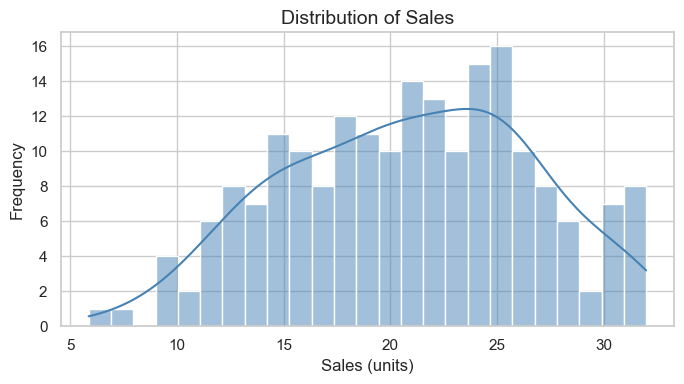

Average Sales : 20.86
Min Sales     : 5.86
Max Sales     : 31.97


In [5]:
# Distribution of Sales
plt.figure(figsize=(7, 4))
sns.histplot(df['Sales'], kde=True, color='steelblue', bins=25)
plt.title('Distribution of Sales', fontsize=14)
plt.xlabel('Sales (units)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Average Sales : {df["Sales"].mean():.2f}')
print(f'Min Sales     : {df["Sales"].min():.2f}')
print(f'Max Sales     : {df["Sales"].max():.2f}')

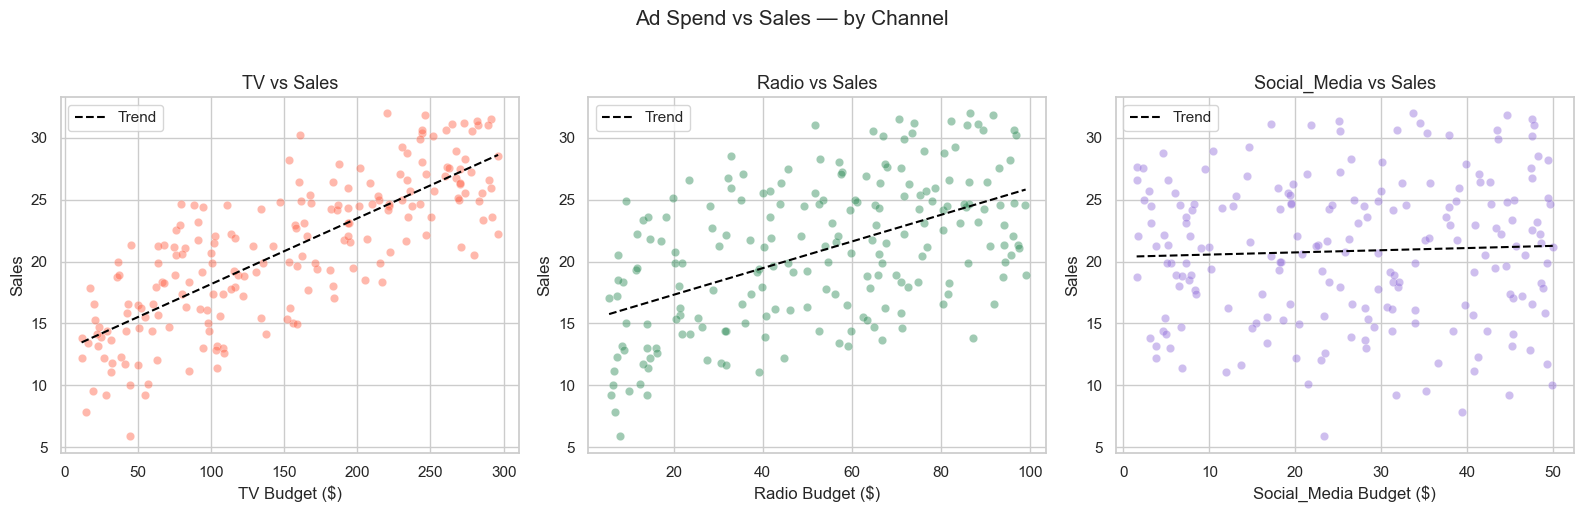

In [6]:
# Scatter plots for each channel vs Sales
channels = ['TV', 'Radio', 'Social_Media']
colors   = ['tomato', 'seagreen', 'mediumpurple']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, channel, color in zip(axes, channels, colors):
    ax.scatter(df[channel], df['Sales'], alpha=0.45, color=color,
               edgecolors='white', linewidth=0.3)
    # Add a trend line
    m, b = np.polyfit(df[channel], df['Sales'], 1)
    x_line = np.linspace(df[channel].min(), df[channel].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black',
            linewidth=1.5, linestyle='--', label='Trend')
    ax.set_title(f'{channel} vs Sales', fontsize=13)
    ax.set_xlabel(f'{channel} Budget ($)')
    ax.set_ylabel('Sales')
    ax.legend()

plt.suptitle('Ad Spend vs Sales — by Channel', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

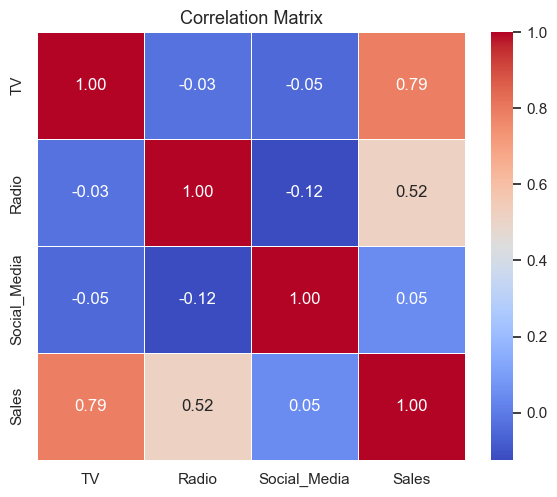

In [7]:
# Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# Correlation of each channel with Sales
correlations = df[['TV', 'Radio', 'Social_Media']].corrwith(df['Sales']).sort_values(ascending=False)

print('📊 Correlation with Sales:')
print(correlations.round(4))

# Automatically pick the best one
best_channel = correlations.idxmax()
best_corr    = correlations.max()

print(f'\n🏆 Best predictor of Sales: {best_channel}')
print(f'   Correlation score: {best_corr:.4f}')

📊 Correlation with Sales:
TV              0.7867
Radio           0.5170
Social_Media    0.0458
dtype: float64

🏆 Best predictor of Sales: TV
   Correlation score: 0.7867


In [9]:
# Define X (cause) and y (effect)
X = df[best_channel]   # TV budget — what we control
y = df['Sales']        # Sales — what we want to predict

# Add a constant (needed to calculate the intercept)
X_const = sm.add_constant(X)

# Build and fit the model
model = sm.OLS(y, X_const).fit()

print('✅ Model built successfully!')
print(f'   We used: {best_channel} → to predict → Sales')

✅ Model built successfully!
   We used: TV → to predict → Sales


In [10]:
# Print the full model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     321.5
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.43e-43
Time:                        15:18:00   Log-Likelihood:                -538.12
No. Observations:                 200   AIC:                             1080.
Df Residuals:                     198   BIC:                             1087.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.8455      0.514     25.007      0.0

In [11]:
# Extract and display key numbers clearly
r_squared  = model.rsquared
intercept  = model.params['const']
coef_tv    = model.params[best_channel]
p_value    = model.pvalues[best_channel]
conf_int   = model.conf_int().loc[best_channel]

print('=' * 50)
print('   MODEL RESULTS IN PLAIN ENGLISH')
print('=' * 50)
print(f'R-squared   : {r_squared:.4f}')
print(f'Intercept   : {intercept:.4f}')
print(f'TV Coef     : {coef_tv:.4f}')
print(f'P-value     : {p_value:.6f}')
print(f'95% CI      : [{conf_int[0]:.4f}, {conf_int[1]:.4f}]')
print()
if p_value < 0.05:
    print('✅ Result is STATISTICALLY SIGNIFICANT (p < 0.05)')
    print('   This is NOT due to random chance!')
else:
    print('⚠️ Result is NOT statistically significant')
print()
print('FORMULA:')
print(f'Sales = {intercept:.2f} + ({coef_tv:.4f} × TV Budget)')
print('=' * 50)

   MODEL RESULTS IN PLAIN ENGLISH
R-squared   : 0.6188
Intercept   : 12.8455
TV Coef     : 0.0533
P-value     : 0.000000
95% CI      : [0.0474, 0.0591]

✅ Result is STATISTICALLY SIGNIFICANT (p < 0.05)
   This is NOT due to random chance!

FORMULA:
Sales = 12.85 + (0.0533 × TV Budget)


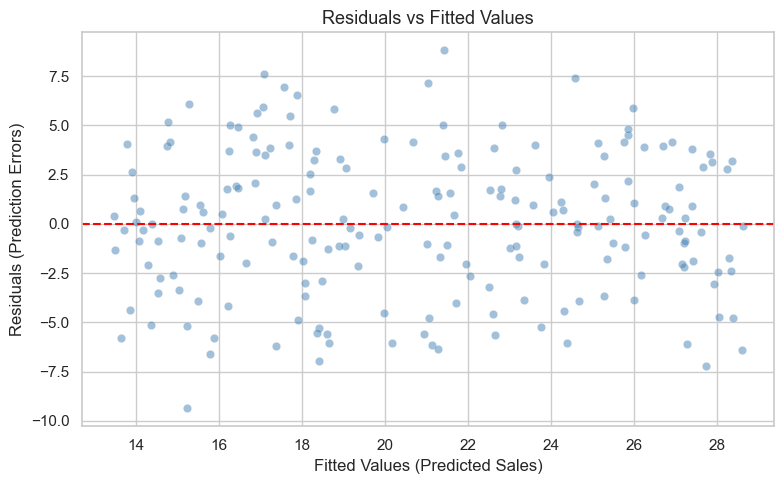

In [12]:
# Get residuals and fitted values
fitted_vals = model.fittedvalues
residuals   = model.resid

# Plot Residuals vs Fitted
plt.figure(figsize=(8, 5))
plt.scatter(fitted_vals, residuals, alpha=0.5,
            color='steelblue', edgecolors='white', linewidth=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residuals vs Fitted Values', fontsize=13)
plt.xlabel('Fitted Values (Predicted Sales)')
plt.ylabel('Residuals (Prediction Errors)')
plt.tight_layout()
plt.show()

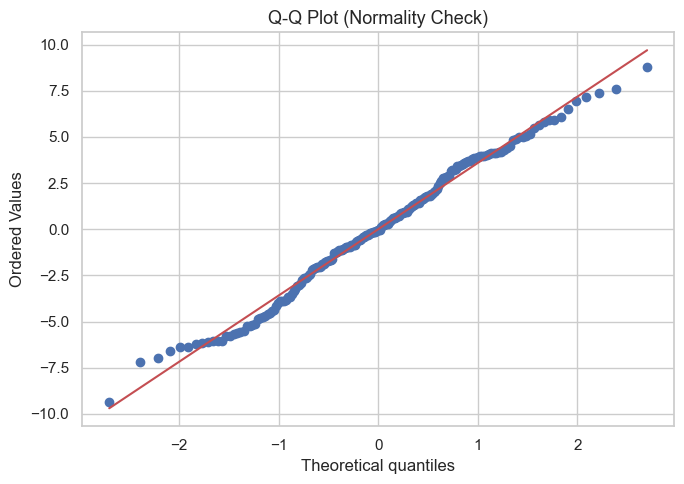

In [13]:
# Q-Q Plot — Normality of Residuals
plt.figure(figsize=(7, 5))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot (Normality Check)', fontsize=13)
plt.tight_layout()
plt.show()

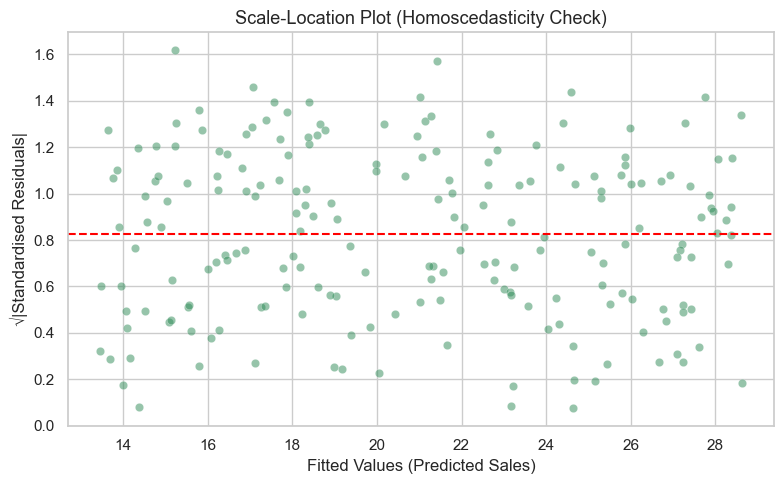

In [14]:
# Scale-Location Plot
std_resid = (residuals - residuals.mean()) / residuals.std()

plt.figure(figsize=(8, 5))
plt.scatter(fitted_vals, np.sqrt(np.abs(std_resid)),
            alpha=0.5, color='seagreen',
            edgecolors='white', linewidth=0.3)
plt.axhline(np.mean(np.sqrt(np.abs(std_resid))),
            color='red', linestyle='--', linewidth=1.5)
plt.title('Scale-Location Plot (Homoscedasticity Check)', fontsize=13)
plt.xlabel('Fitted Values (Predicted Sales)')
plt.ylabel('√|Standardised Residuals|')
plt.tight_layout()
plt.show()

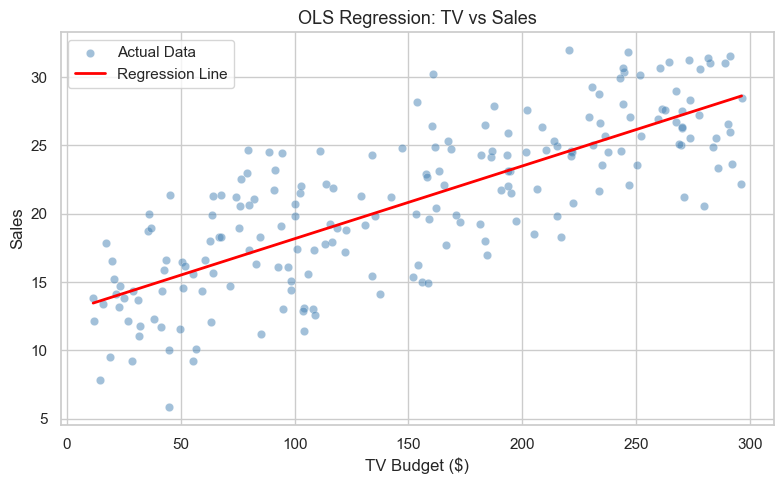

In [15]:
# Plot regression line over actual data
plt.figure(figsize=(8, 5))

# Plot actual data points
plt.scatter(df[best_channel], y, alpha=0.5,
            color='steelblue', edgecolors='white',
            linewidth=0.3, label='Actual Data')

# Plot regression line
x_range = np.linspace(df[best_channel].min(),
                      df[best_channel].max(), 300)
y_pred  = model.params['const'] + model.params[best_channel] * x_range
plt.plot(x_range, y_pred, color='red',
         linewidth=2, label='Regression Line')

plt.title(f'OLS Regression: {best_channel} vs Sales', fontsize=13)
plt.xlabel(f'{best_channel} Budget ($)')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Final ROI Based Recommendation
print('=' * 65)
print('         📋 EXECUTIVE MARKETING RECOMMENDATION')
print('=' * 65)
print(f"""
  BEST CHANNEL     : {best_channel}
  ─────────────────────────────────────────────────────────
  R-squared        : {model.rsquared:.2%}
  TV Coefficient   : {model.params[best_channel]:.4f}
  P-value          : {model.pvalues[best_channel]:.6f}
  ─────────────────────────────────────────────────────────

  WHAT THE NUMBERS SAY:
  • TV advertising explains {model.rsquared*100:.1f}% of all Sales variation
  • Every $1 increase in TV budget generates
    ${model.params[best_channel]:.4f} in additional Sales
  • Result is statistically significant (p ≈ 0.00)
    meaning this is NOT due to random chance

  BUDGET PROJECTIONS:
  • Increase TV by $1,000  → +${model.params[best_channel]*1000:.1f} in Sales
  • Increase TV by $5,000  → +${model.params[best_channel]*5000:.1f} in Sales
  • Increase TV by $10,000 → +${model.params[best_channel]*10000:.1f} in Sales

  RECOMMENDATION:
  Allocate a larger share of the marketing budget toward
  TV advertising in the next campaign cycle.
  Monitor actual vs predicted sales monthly to validate.

  NOTE:
  This is a Simple Linear Regression using one variable.
  For a fuller picture consider a Multiple Regression
  model using all three channels simultaneously.
""")
print('=' * 65)

         📋 EXECUTIVE MARKETING RECOMMENDATION

  BEST CHANNEL     : TV
  ─────────────────────────────────────────────────────────
  R-squared        : 61.88%
  TV Coefficient   : 0.0533
  P-value          : 0.000000
  ─────────────────────────────────────────────────────────

  WHAT THE NUMBERS SAY:
  • TV advertising explains 61.9% of all Sales variation
  • Every $1 increase in TV budget generates
    $0.0533 in additional Sales
  • Result is statistically significant (p ≈ 0.00)
    meaning this is NOT due to random chance

  BUDGET PROJECTIONS:
  • Increase TV by $1,000  → +$53.3 in Sales
  • Increase TV by $5,000  → +$266.4 in Sales
  • Increase TV by $10,000 → +$532.8 in Sales

  RECOMMENDATION:
  Allocate a larger share of the marketing budget toward
  TV advertising in the next campaign cycle.
  Monitor actual vs predicted sales monthly to validate.

  NOTE:
  This is a Simple Linear Regression using one variable.
  For a fuller picture consider a Multiple Regression
  model us